In [ ]:
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

# ==========================================
# 1. PENGATURAN PATH & CONFIGURATION
# ==========================================
# Pastikan script python ini berada di folder yang sama dengan folder 'data'
DATA_DIR = "datasetBuah2/train/train" 
IMG_SIZE = (224, 224) # Mengubah semua ukuran gambar menjadi 224x224 piksel
BATCH_SIZE = 32

# ==========================================
# 2. LOADING DATASET (Otomatis Split Train & Val)
# ==========================================
# Memuat data untuk Training (80%)
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Memuat data untuk Validasi/Testing (20%)
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Mengambil nama-nama kelas berdasarkan nama folder
class_names = train_ds.class_names
num_classes = len(class_names)
print(f"\nTotal Kelas ditemukan: {num_classes}")
print(f"Daftar Kelas: {class_names}\n")

# Optimasi performa loading data ke memori
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# ==========================================
# 3. MEMBANGUN MODEL CNN (Convolutional Neural Network)
# ==========================================
model = models.Sequential([
    # Rescaling untuk mengubah nilai pixel dari 0-255 menjadi 0-1
    layers.Rescaling(1./255, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    
    # Feature Extraction (Mempelajari pola gambar)
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Flattening & Fully Connected Layer (Klasifikasi keputusan)
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # Mencegah overfitting
    layers.Dense(num_classes, activation='softmax') # Output sesuai jumlah kelas
])

# ==========================================
# 4. COMPILE & TRAINING MODEL
# ==========================================
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

model.summary()

# Mulai proses training (silakan naikkan epochs jika akurasi kurang tinggi)
EPOCHS = 50
print("\nMemulai Training Model...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

# ==========================================
# 5. MENYIMPAN MODEL
# ==========================================
model.save('model_klasifikasi_makanan.h5')
print("\nModel sukses dilatih dan disimpan dengan nama 'model_klasifikasi_makanan.h5'!")

Found 16854 files belonging to 33 classes.
Using 13484 files for training.
Found 16854 files belonging to 33 classes.
Using 3370 files for validation.

Total Kelas ditemukan: 33
Daftar Kelas: ['Apple Braeburn', 'Apple Granny Smith', 'Apricot', 'Avocado', 'Banana', 'Blueberry', 'Cactus fruit', 'Cantaloupe', 'Cherry', 'Clementine', 'Corn', 'Cucumber Ripe', 'Grape Blue', 'Kiwi', 'Lemon', 'Limes', 'Mango', 'Onion White', 'Orange', 'Papaya', 'Passion Fruit', 'Peach', 'Pear', 'Pepper Green', 'Pepper Red', 'Pineapple', 'Plum', 'Pomegranate', 'Potato Red', 'Raspberry', 'Strawberry', 'Tomato', 'Watermelon']



c:\Users\foral\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 33)             │         4,257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,173,217 (42.62 MB)

 Trainable params: 11,173,217 (42.62 MB)

 Non-trainable params: 0 (0.00 B)


Memulai Training Model...
Epoch 1/50



Membuat Grafik Training...


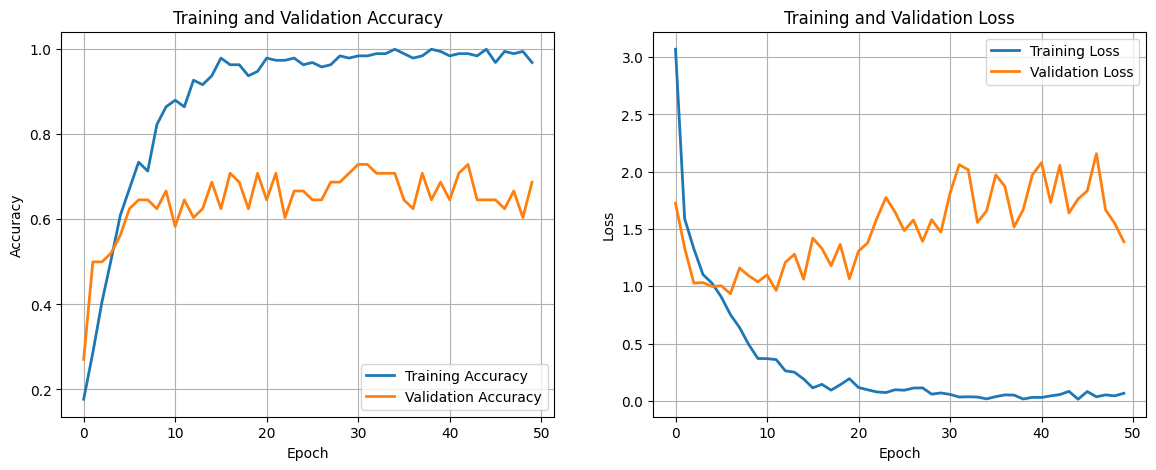


Menghitung Classification Report...
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step

--- CLASSIFICATION REPORT ---
                  precision    recall  f1-score   support

     apple fruit       0.60      0.75      0.67         4
    banana fruit       0.56      0.62      0.59         8
    grapes fruit       0.73      0.79      0.76        14
     mango fruit       0.50      0.60      0.55         5
    orange fruit       0.80      0.67      0.73         6
strawberry fruit       0.88      0.64      0.74        11

        accuracy                           0.69        48
       macro avg       0.68      0.68      0.67        48
    weighted avg       0.71      0.69      0.69        48


Membuat Confusion Matrix...


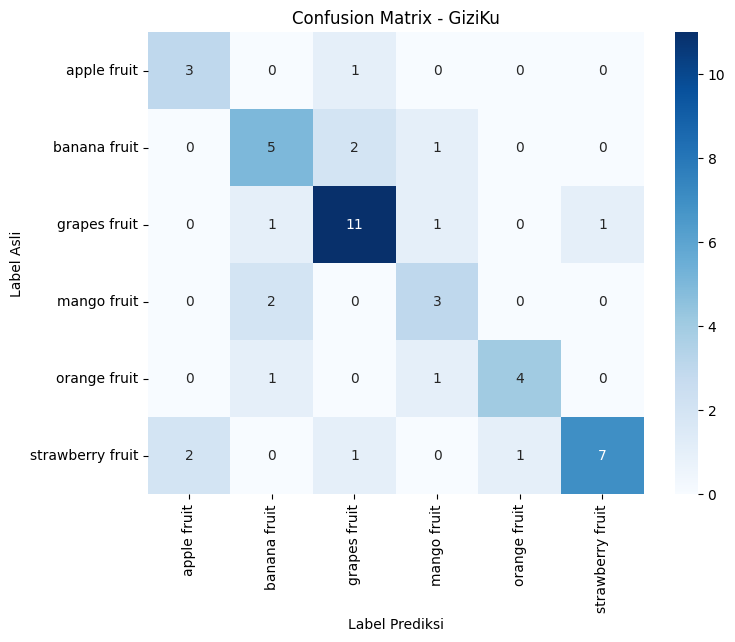

In [2]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns # Opsional, untuk visualisasi confusion matrix yang lebih rapi

# ==========================================
# 6. VISUALISASI GRAFIK TRAINING (ACCURACY & LOSS)
# ==========================================
print("\nMembuat Grafik Training...")
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(14, 5))

# Grafik Akurasi
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', linewidth=2)
plt.plot(epochs_range, val_acc, label='Validation Accuracy', linewidth=2)
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)

# Grafik Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', linewidth=2)
plt.plot(epochs_range, val_loss, label='Validation Loss', linewidth=2)
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

# Simpan grafik sebagai file gambar
plt.savefig('grafik_training_giziku.png')
plt.show()

# ==========================================
# 7. EVALUASI MODEL (CLASSIFICATION REPORT & CONFUSION MATRIX)
# ==========================================
print("\nMenghitung Classification Report...")

# Mengambil label asli (ground truth) dari validation dataset
y_true = np.concatenate([y for x, y in val_ds], axis=0)

# Melakukan prediksi terhadap dataset validasi
predictions = model.predict(val_ds)
y_pred = np.argmax(predictions, axis=1)

# Mencetak Classification Report
print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(y_true, y_pred, target_names=class_names))

# (Opsional) Membuat visualisasi Confusion Matrix
print("\nMembuat Confusion Matrix...")
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - GiziKu')
plt.ylabel('Label Asli')
plt.xlabel('Label Prediksi')
plt.savefig('confusion_matrix_giziku.png')
plt.show()

In [3]:
import numpy as np
import tensorflow as tf

# Load kembali model yang sudah dilatih
model = tf.keras.models.load_model('model_klasifikasi_makanan.h5')

# Daftar kelas harus urut sesuai abjad (sama seperti saat training)
class_names = ['apple fruit', 'banana fruit', 
               'grapes fruit',  'mango fruit',
               'orange fruit', 'strawberry fruit', ]

# Ganti dengan path foto makanan/buah yang mau kamu tes
img_path = 'D:\Rixh\data\strawberry fruit\Image_35.jpg' 

# Load gambar dan sesuaikan ukurannya
img = tf.keras.utils.load_img(img_path, target_size=(224, 224))
img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0) # Buat batch axis

# Prediksi gambar
predictions = model.predict(img_array)
score = tf.nn.softmax(predictions[0])

# Tampilkan hasil
print(f"Gambar ini kemungkinan besar adalah: {class_names[np.argmax(score)]} "
      f"dengan tingkat keyakinan {100 * np.max(score):.2f}%.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Gambar ini kemungkinan besar adalah: strawberry fruit dengan tingkat keyakinan 35.22%.
